# <u>Multiple Linear Regression</u>

## Topics

* [1. Problem setup](#setup)
* [2. Assumptions for Simple Linea Regression](#assume)
* [3. Core Minimization problem (OLS)](#min)
* [4. Model Quality](#quality)
* [5. Statistical Inference](#stats)
* [6. (Batch) Gradient Descent](#gd)
* [7. Stochastic Gradient Descent (SGD)](#sgd)
    



In [ ]:
import numpy as np # for random numbers and matrix calculus
import matplotlib.pyplot as plt # for plotting
import pandas as pd # for creating dataframes
import scipy.stats as stats # for Q-Q Plot
import statsmodels.api as sm # # for Statistical Inference
from scipy.stats import t,f # for Students t and F distribtuion
from scipy.stats import multivariate_normal # multivariate normal distribution
import plotly.graph_objects as go # interactive 3D plots but more complex
import plotly.express as px # also for interactive 3D plots but more simple

<a class="anchor" id="setup"></a>
## 1. Problem setup

In this notebook, I will introduce **Multiple Linear Regression**, a method used to predict a target (dependent variable) based on <u>multiple</u> features (independent variables).

The goal is to learn the relationship between the **features (predictors)** and the **target variable** using a linear model.

---

### Variables

* **$y$** — target vector of length $n$
* **$x_1$** — 1st feature vector of length $n$
* **$x_2$** — 2nd feature vector of length $n$
* $\vdots$
* **$x_p$** — $p$-th feature vector of length $n$

---

### Model (scalar form)

For each observation $i = 1, \dots, n$:

$$
y^{(i)} = \theta^\top x^{(i)} + \varepsilon^{(i)} 
= \theta_0 + \theta_1 x_1^{(i)} + \ldots + \theta_p x_p^{(i)} + \varepsilon^{(i)}
$$

where:

- $\theta = (\theta_0, \theta_1, \ldots, \theta_p) \in \mathbb{R}^{p+1}$ is the parameter vector  
- $x^{(i)} = (1, x_1^{(i)}, \ldots, x_p^{(i)}) \in \mathbb{R}^{p+1}$ is the feature vector (including intercept)  
- $\varepsilon^{(i)}$ is the error term capturing noise or unobserved factors  

---

### Prediction Model

The estimated model is:

$$
\hat{y}^{(i)} = \hat{\theta}^\top x^{(i)} 
= \hat{\theta}_0 + \hat{\theta}_1 x_1^{(i)} + \ldots + \hat{\theta}_p x_p^{(i)}
$$

where:

- $\hat{\theta}=(\hat{\theta}_0, \hat{\theta}_1, \ldots, \hat{\theta}_p) \in \mathbb{R}^{p+1}$ are the estimated parameters  
- $\hat{\theta}_j$ represents the effect of feature $x_j$ on the target $j=1,...,p$  
- $\hat{\theta}_0$ is the intercept (baseline prediction when all features are zero)  

---

### Matrix Formulation

We can express the model compactly using matrix notation:

$$
y = X\theta + \varepsilon
$$

where:

$$
y =
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{pmatrix}, 
\quad
X =
\begin{pmatrix}
1 & x_1^{(1)} & \ldots & x_p^{(1)} \\
1 & x_1^{(2)} & \ldots & x_p^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(n)} & \ldots & x_p^{(n)}
\end{pmatrix},
\quad
\theta =
\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_p
\end{pmatrix}
$$

---

### Predictions in Matrix Form

$$
\hat{y} = X\hat{\theta}
$$

where:

$$
\hat{y} =
\begin{pmatrix}
\hat{y}^{(1)} \\
\hat{y}^{(2)} \\
\vdots \\
\hat{y}^{(n)}
\end{pmatrix}
$$

---

### &#128161; Interpretation

- Each row of $X$ represents one observation  
- Each column (except the first) represents a feature  
- The first column of ones accounts for the intercept  
- The model is **linear in the parameters** (even if features are transformed)



<a class="anchor" id="assume"></a>
## 2. Assumptions for Multiple Linear Regression

| Assumption | Description | Consequence | Verification |
|-----------|------------|-------------|--------------|
| **Linearity** | The relationship between the predictors and the target is linear in the parameters: $y = X\theta + \varepsilon$. |  Ensures unbiased and consistent estimates of $\hat{\theta}$ | Residuals vs. Fitted Plot, Partial regression plots |
| **Independent Errors** | Error terms are independent: $\varepsilon^{(i)}$ independent of $\varepsilon^{(j)}$ for $i \neq j$. |  Valid statistical inference (standard errors, hypothesis tests) | Residuals vs. Order Plot, Durbin–Watson test |
| **Homoscedasticity** | Constant variance of errors: $\mathrm{Var}(\varepsilon^{(i)}) = \sigma^2$ for all $i$; $\mathrm{Cov}(\varepsilon)=\sigma^2 I_n$ ,  $\sigma^2 \ge 0$ |  Correct standard errors and confidence intervals | Residuals vs. Fitted Plot |
| **Zero Mean Errors** | Errors are centered at zero: $\mathrm{E}[\varepsilon^{(i)}] = 0$. |  Ensures unbiasedness of $\hat{\theta}$ | Check mean of residuals (should be $\approx 0$) |
| **Normality of Errors  $\varepsilon^{(i)} \sim \mathcal{N}(0,\sigma^2)$** | Errors follow a normal distribution |  Enables exact inference (t-tests, F-tests, confidence intervals) | Q–Q plot of residuals, Histogram of residuals |
| **No Extreme Outliers / Influential Points** | No single observation should dominate the model fit. |  Stability of estimates and inference | Leverage plots, Cook’s distance, Residuals vs. Fitted |
| **Full Rank of $X$ (No Multicollinearity)** | The regression matrix $X$ has full column rank: $\text{rank}(X) = p+1 < n$. |  Unique solution $\hat{\theta} = (X^\top X)^{-1}X^\top y$ exists | Correlation matrix, Variance Inflation Factor (VIF) |


### Linearity

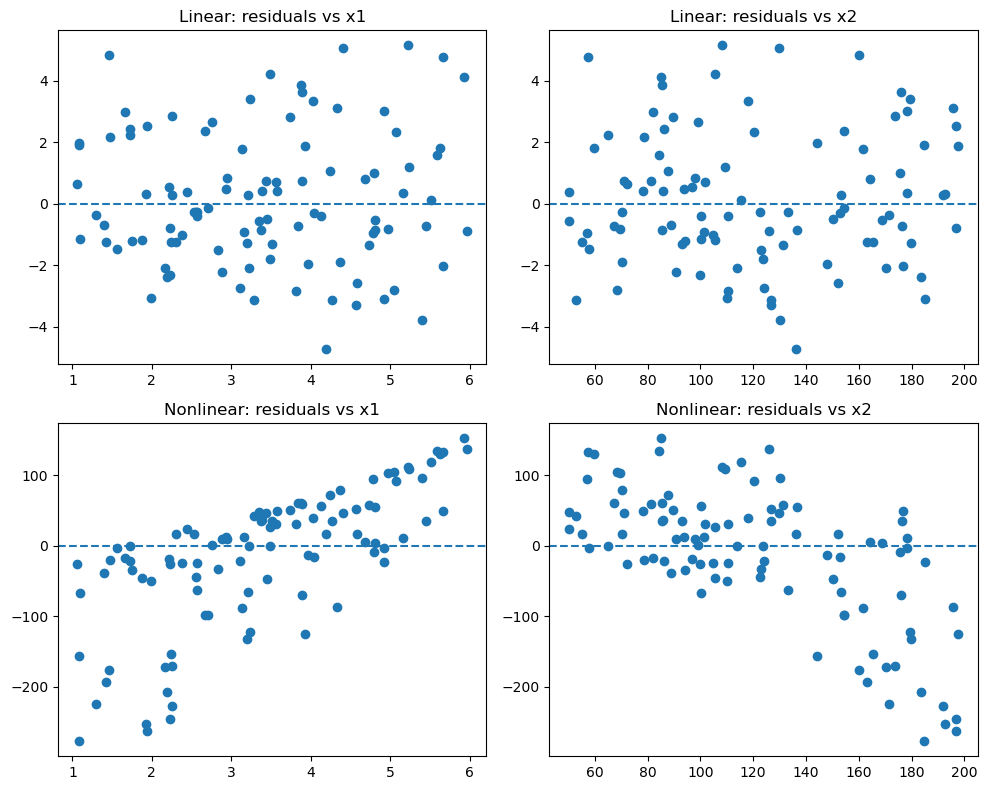

In [18]:
np.random.seed(1742) # for reproducibility of random numbers

n = 100 # number of observation/sample size

# Features
x_1 = np.random.uniform(1, 6, n) # e.g. number of rooms
x_2 = np.random.uniform(50, 200, n) # e.g. house size

X = np.column_stack([np.ones(n), x_1, x_2]) # regresion matrix

beta = np.array([5, 10, 0.5]) # parameter vector


# Linear data
true_y = X @ beta
error = np.random.normal(0, 2, n)
y = true_y + error

res = y - (X @ beta) # residuals


# Nonlinear data
true_y_nl = (
    5
    + 10 * x_1
    + 0.5 * x_2
    + 2 * (x_1**2) # curvature
    - 0.01 * (x_2**2) # curvature
    + 0.3 * (x_1 * x_2) # interaction
)

y_nl = true_y_nl + error

# linear model applied to nonlinear data to to show that a linear model is inappropriate
y_hat_linear = X @ beta
res_nl = y_nl - y_hat_linear


# 3D Plot Linear data
fig1 = px.scatter_3d(
    x=x_1, y=x_2, z=y,
    title="Linear Data",
    labels={'x':'x1', 'y':'x2', 'z':'y'}
)

# Create grid
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x_1.min(), x_1.max(), 20),
    np.linspace(x_2.min(), x_2.max(), 20)
)

grid_y = 5 + 10*grid_x1 + 0.5*grid_x2  # true linear model

# Add plane
fig1.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        opacity=0.4,
        showscale=False,
        name="True Plane",
        showlegend=True  
    )
)

fig1.update_layout(width=700, height=500)
fig1.show()


# 3D Plot Nonlinear data
fig2 = px.scatter_3d(
    x=x_1, y=x_2, z=y_nl,
    title="Nonlinear Data",
    labels={'x':'x1', 'y':'x2', 'z':'y'}
)

# Same linear plane (wrong model)
fig2.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        opacity=0.4,
        showscale=False,
        name="Linear Fit (Wrong Model)",
        showlegend=True  
    )
)


fig2.update_layout(width=700, height=500)
fig2.show()


# Residuals Plot
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Linear case
axes[0,0].scatter(x_1, res)
axes[0,0].axhline(0, linestyle="--")
axes[0,0].set_title("Linear: residuals vs x1")

axes[0,1].scatter(x_2, res)
axes[0,1].axhline(0, linestyle="--")
axes[0,1].set_title("Linear: residuals vs x2")


# Nonlinear case
axes[1,0].scatter(x_1, res_nl)
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Nonlinear: residuals vs x1")

axes[1,1].scatter(x_2, res_nl)
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Nonlinear: residuals vs x2")

plt.tight_layout()
plt.show()

<a class="anchor" id="min"></a>
## 3. Core Minimization problem (Ordinary Least Squares)





<a class="anchor" id="quality"></a>
## 4. Model Quality




<a class="anchor" id="stats"></a>
## 5. Statistical Inference

In Simple Linear Regression, statistical inference is used to draw conclusions about the population relationship between 
$X$ (aka *Size*) and $Y$ (aka *Price*) based on the sample data.

The main statistical inference methods are listed as follows:


| Method                                | Purpose                               |
| ------------------------------------- | ------------------------------------- |
| t-test/F-test for $\beta_1$                  | Test if $X$ significantly affects $Y$ |
| t-test/F-test for $\beta_0$                  | Test intercept significance           |
| Confidence intervals                  | Estimate plausible parameter values for $\beta_0$ and $\beta_1$   |



<a class="anchor" id="gd"></a>
## 6. (Batch) Gradient Descent

<a class="anchor" id="sgd"></a>
## 7. Stochastic Gradient Descent (SGD)